In [ ]:
# Fine-Tuning (Xlm-r)(without pre-process+weighted)

# Part 1: Install Required Libraries

In [ ]:
!pip uninstall -y transformers torchvision torch torchaudio accelerate -q

!pip install -q \
torch==2.7.1 \
torchvision==0.22.1 \
torchaudio==2.7.1 \
--index-url https://download.pytorch.org/whl/cu128

!pip install -q \
transformers==4.53.3 \
accelerate==1.8.1 \
datasets==4.0.0 \
evaluate==0.4.5 \
sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 63.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 147.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 105.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 726.9/726.9 MB 46.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 609.6/609.6 MB 61.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 32.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 59.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.4/260.4 MB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.1/292.1 MB 68.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 101.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 75.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 92.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Mount Google Drive to access datasets and save/load model checkpoints
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports Libraries
import os
import gc
import random
import warnings

import numpy as np
import pandas as pd

import torch
import evaluate

from datasets import Dataset

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

warnings.filterwarnings("ignore")

In [ ]:
# Set random seed for reproducibility across numpy, random, and torch
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [ ]:
# Check whether a GPU is available and select the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Device : cuda
GPU : Tesla T4


In [ ]:
# Path to the MLM-pretrained XLM-R checkpoint (used as the starting point for fine-tuning)
MLM_MODEL_PATH = "/content/drive/MyDrive/Avanee/Best_XLMR_MLM8"

In [ ]:
# Load the tokenizer that matches the MLM-pretrained model
tokenizer = AutoTokenizer.from_pretrained(MLM_MODEL_PATH)

print("Tokenizer Loaded Successfully")

Tokenizer Loaded Successfully


In [ ]:
# Load the MLM-pretrained XLM-R model (will later be swapped for a classification head)
mlm_model = AutoModelForMaskedLM.from_pretrained(
    MLM_MODEL_PATH
)

print("MLM Model Loaded Successfully")

MLM Model Loaded Successfully


# Part 2: Define paths to the raw dataset files (to be loaded and merged next)

In [ ]:
# Load and Merge Datasets
ENGLISH_PATH = "/content/English_train_data.csv"

HINDI_PATH = "/content/english_to_hindi.csv"

BENGALI_PATH = "/content/english_to_bengali.csv"

NONE_PATH = "/content/non_climate_none.csv"


In [ ]:
# Load each dataset from its CSV file
english_df = pd.read_csv(ENGLISH_PATH)
hindi_df = pd.read_csv(HINDI_PATH)
bengali_df = pd.read_csv(BENGALI_PATH)
none_df = pd.read_csv(NONE_PATH)

print("English :", english_df.shape)
print("Hindi   :", hindi_df.shape)
print("Bengali :", bengali_df.shape)
print("NONE    :", none_df.shape)

English : (12771, 2)
Hindi   : (12771, 3)
Bengali : (12771, 3)
NONE    : (10000, 2)


In [ ]:
# Check column names before selecting/renaming the relevant ones
print("English Columns :", english_df.columns.tolist())
print("Hindi Columns   :", hindi_df.columns.tolist())
print("Bengali Columns :", bengali_df.columns.tolist())
print("NONE Columns    :", none_df.columns.tolist())

English Columns : ['sentence', 'label']
Hindi Columns   : ['sentence', 'label', 'hindi']
Bengali Columns : ['sentence', 'label', 'bengali']
NONE Columns    : ['sentence', 'label']


In [ ]:
# Keep only the text and label columns, and rename them to a common
# "sentence" / "label" schema so all datasets can be concatenated
hindi = hindi_df[["hindi","label"]].copy()
hindi.columns = ["sentence","label"]

bengali = bengali_df[["bengali","label"]].copy()
bengali.columns = ["sentence","label"]

english = english_df[["sentence","label"]].copy()

none_df = none_df[["sentence","label"]].copy()

In [ ]:
# Concatenate all language datasets into a single training dataframe
train_df = pd.concat(
    [
        english,
        hindi,
        bengali,
        none_df
    ],
    ignore_index=True
)

print("Merged Dataset :", train_df.shape)

Merged Dataset : (48313, 2)


In [ ]:
# Drop rows with missing values and blank/whitespace-only sentences
train_df.dropna(inplace=True)

train_df["sentence"] = train_df["sentence"].astype(str)

train_df = train_df[
    train_df["sentence"].str.strip() != ""
]

print(train_df.shape)

(48313, 2)


In [ ]:
# Remove duplicate sentences to avoid data leakage/repetition
before = len(train_df)

train_df.drop_duplicates(
    subset=["sentence"],
    inplace=True
)

after = len(train_df)

print("Duplicates Removed :", before-after)

Duplicates Removed : 448


In [ ]:
# Shuffle the merged dataset so languages/classes are interleaved
train_df = train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [ ]:
# Check the class distribution after merging and cleaning
print(train_df["label"].value_counts())

label
NONE       22650
AGAINST    12610
FAVOR      12605
Name: count, dtype: int64


In [ ]:
# Save the cleaned, merged dataset to Drive so it can be reloaded later
SAVE_PATH = "/content/drive/MyDrive/XLM-R Cross Validation/final_training_dataset.csv"

train_df.to_csv(
    SAVE_PATH,
    index=False
)

print("Saved Successfully")
print(SAVE_PATH)

Saved Successfully
/content/drive/MyDrive/XLM-R Cross Validation/final_training_dataset.csv


# Part 3: Load the Final Dataset, Encode Labels, and Split into Train/Val

In [ ]:
# Load the Final Dataset
import pandas as pd

train_df = pd.read_csv(
    "/content/drive/MyDrive/XLM-R Cross Validation/final_training_dataset.csv"
)

print(train_df.shape)
train_df.head()

(47865, 2)


,sentence,label
0,"बहरहाल, ग्लोबल वार्मिंग उन्माद के पीछे एक वास्...",AGAINST
1,: চীন খুব সদয়ভাবে ট্রাম্পকে ব্যাখ্যা করেছে যে...,FAVOR
2,उस पर रखें। इस सप्ताह पहले ऐसा ही कुछ सुना था....,NONE
3,আপনি কীভাবে আমাকে বলবেন যে জলবায়ু পরিবর্তন/গ্...,NONE
4,Maybe it's like climate change making all the ...,NONE


In [ ]:
# Check label distribution of the reloaded dataset
print(train_df["label"].value_counts())

label
NONE       22650
AGAINST    12610
FAVOR      12605
Name: count, dtype: int64


In [ ]:
# Encode string labels (AGAINST/FAVOR/NONE) into integers
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["label"])

print(label_encoder.classes_)

['AGAINST' 'FAVOR' 'NONE']


In [ ]:
# Save the label -> integer id mapping produced by the encoder
label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

{'AGAINST': np.int64(0), 'FAVOR': np.int64(1), 'NONE': np.int64(2)}


In [ ]:
# Build the reverse mapping (integer id -> label) for later use in predictions
id2label = {v:k for k,v in label_mapping.items()}

print(id2label)

{np.int64(0): 'AGAINST', np.int64(1): 'FAVOR', np.int64(2): 'NONE'}


In [ ]:
# Stratified train/validation split (keeps class ratios consistent in both splits)
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(

    train_df["sentence"],

    train_df["label"],

    test_size=0.2,

    random_state=42,

    stratify=train_df["label"]

)

In [ ]:
# Verify the resulting split sizes
print("Training Samples :", len(train_texts))
print("Validation Samples :", len(val_texts))

Training Samples : 38292
Validation Samples : 9573


In [ ]:
# Verify class balance is preserved in both the train and validation splits
print(pd.Series(train_labels).value_counts())

print()

print(pd.Series(val_labels).value_counts())

label
2    18120
0    10088
1    10084
Name: count, dtype: int64

label
2    4530
0    2522
1    2521
Name: count, dtype: int64


In [ ]:
# Rebuild train/validation dataframes from the split arrays
train_df = pd.DataFrame({

    "sentence":train_texts,

    "label":train_labels

})

val_df = pd.DataFrame({

    "sentence":val_texts,

    "label":val_labels

})

train_df.reset_index(drop=True,inplace=True)
val_df.reset_index(drop=True,inplace=True)

In [ ]:
# Sanity-check the rebuilt training dataframe
train_df.head()

,sentence,label
0,ive never understood why apple does this they ...,2
1,इस बात का कोई सांख्यिकीय प्रमाण नहीं है कि ग्ल...,0
2,the bounce back between level 1 and 3 were gre...,2
3,मुझे नफ़रत है कि यह कितनी ठंड है। अब ग्लोबल वा...,2
4,building wealth involves developing good habit...,2


# Part 4: Tokenization and Conversion to Hugging Face Datasets

In [ ]:
from datasets import Dataset
from transformers import DataCollatorWithPadding

In [ ]:
# Convert the pandas dataframes into Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['sentence', 'label'],
    num_rows: 38292
})
Dataset({
    features: ['sentence', 'label'],
    num_rows: 9573
})


In [ ]:
# Reload the tokenizer matching the MLM-pretrained checkpoint
from transformers import AutoTokenizer

MODEL_PATH = "/content/drive/MyDrive/Avanee/Best_XLMR_MLM8"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

print("Tokenizer Loaded Successfully")

Tokenizer Loaded Successfully


In [ ]:
# Inspect the tokenized length (in tokens) of each sentence to choose a max sequence length
lengths = train_df["sentence"].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=True))
)

print(lengths.describe())

Token indices sequence length is longer than the specified maximum sequence length for this model (591 > 512). Running this sequence through the model will result in indexing errors


count    38292.000000
mean        33.290034
std         28.672160
min          3.000000
25%         22.000000
50%         30.000000
75%         39.000000
max       1453.000000
Name: sentence, dtype: float64


In [ ]:
# Check the 95th percentile of token lengths to inform the MAX_LEN cutoff below
print(lengths.quantile(0.95))

57.0


In [ ]:
# Max sequence length chosen based on the 95th percentile of token lengths above
MAX_LEN = 57

In [ ]:
# Tokenization function: truncates to MAX_LEN, padding deferred to the data collator
MAX_LEN = 57

def tokenize(batch):

    return tokenizer(

        batch["sentence"],

        truncation=True,

        max_length=MAX_LEN,

        padding=False

    )

In [ ]:
# Apply tokenization to the train and validation datasets
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/38292 [00:00<?, ? examples/s]

Map:   0%|          | 0/9573 [00:00<?, ? examples/s]

In [ ]:
# Drop the raw text column now that it has been tokenized
train_dataset = train_dataset.remove_columns(["sentence"])

val_dataset = val_dataset.remove_columns(["sentence"])

In [ ]:
# Rename "label" to "labels", the column name expected by the Trainer
train_dataset = train_dataset.rename_column(
    "label",
    "labels"
)

val_dataset = val_dataset.rename_column(
    "label",
    "labels"
)

In [ ]:
# Set dataset output format to PyTorch tensors
train_dataset.set_format("torch")

val_dataset.set_format("torch")

In [ ]:
# Dynamic padding collator: pads each batch to its own longest sequence
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
# Inspect a sample row (temporarily switching to pandas format for readability)
train_dataset.set_format("pandas")
print(train_dataset[0])
train_dataset.set_format("torch") # Revert to torch format

   labels                                          input_ids  \
0       2  [0, 17, 272, 8306, 217064, 15400, 108787, 1460...   

                                      attention_mask  
0  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...  


# Part 5: Load the MLM-Pretrained XLM-R Backbone with a Classification Head

In [ ]:
# Imports
import torch
from transformers import (
    AutoConfig,
    AutoModelForSequenceClassification
)

In [ ]:
# Label <-> id mapping for the 3-way stance classification task
label2id = {
    "AGAINST": 0,
    "FAVOR": 1,
    "NONE": 2
}

id2label = {
    0: "AGAINST",
    1: "FAVOR",
    2: "NONE"
}

In [ ]:
# Load the base config and update it for 3-class sequence classification
MODEL_PATH = "/content/drive/MyDrive/Avanee/Best_XLMR_MLM8"

config = AutoConfig.from_pretrained(MODEL_PATH)

config.num_labels = 3
config.label2id = label2id
config.id2label = id2label

In [ ]:
# Load the MLM-pretrained weights into a sequence classification model
# (ignore_mismatched_sizes=True since the classification head is newly initialized)
model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_PATH,

    config=config,

    ignore_mismatched_sizes=True

)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at /content/drive/MyDrive/Avanee/Best_XLMR_MLM8 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Move the model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


In [ ]:
# Confirm the classification head has the expected number of labels
print(model.config.num_labels)

3


In [ ]:
# Count total vs. trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 278,045,955
Trainable Parameters : 278,045,955


In [ ]:
# Freeze the embedding layer so only the encoder layers and classification
# head are updated during fine-tuning
for param in model.roberta.embeddings.parameters():
    param.requires_grad = False

print("Embedding layer frozen.")

Embedding layer frozen.


In [ ]:
# Print the full model architecture for verification
print(model)

XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=

In [ ]:
# Metrics used for evaluation during and after training
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

# Part 6: Training Arguments and Trainer Setup

In [ ]:
# Function passed to the Trainer to compute accuracy/precision/recall/F1 each eval step
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro"
    )

    return {

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1

    }

In [ ]:
# Training hyperparameters: 10 epochs, cosine LR schedule with warmup,
# mixed precision (fp16), and the best checkpoint (by macro F1) kept at the end
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./XLMR_Climate",

    num_train_epochs=10,

    learning_rate=2e-5,

    weight_decay=0.01,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=32,

    gradient_accumulation_steps=2,

    warmup_ratio=0.10,

    lr_scheduler_type="cosine",

    fp16=True,

    logging_strategy="epoch",

    eval_strategy="epoch",

    save_strategy="epoch",

    save_total_limit=2,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    seed=42,

    report_to="none"
)

In [ ]:
# Stop training early if macro F1 doesn't improve for 3 consecutive evaluations
from transformers import EarlyStoppingCallback

early_stop = EarlyStoppingCallback(

    early_stopping_patience=3

)

# Part 7: Weighted Cross-Entropy Fine-Tuning + Confusion Matrix + Classification Report

In [ ]:
# Compute per-class weights (inverse to class frequency) to counter class imbalance
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Labels from training dataframe
labels = train_df["label"].values

# Compute balanced class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class Weights:", class_weights)

Class Weights: tensor([1.2653, 1.2658, 0.7044])


In [ ]:
# Move the class weights tensor to the same device as the model
class_weights = class_weights.to(device)

In [ ]:
# Custom Trainer that applies the class weights inside a weighted
# CrossEntropyLoss, instead of the Trainer's default unweighted loss
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(
            weight=class_weights
        )

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [ ]:
# Re-create the Trainer using WeightedTrainer (weighted loss) for the second training run

trainer = WeightedTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[early_stop]
)


In [ ]:
# Fine-tune again, this time with the class-weighted loss
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.073400,0.898362,0.825133,0.816805,0.824541,0.819431
2,0.104500,0.857703,0.821164,0.818489,0.827318,0.817199
3,0.088300,1.029323,0.827954,0.818595,0.826584,0.822112
4,0.075700,1.068448,0.825655,0.819601,0.829249,0.820962
5,0.063100,1.125091,0.830774,0.822472,0.842465,0.827420
6,0.050200,1.095360,0.838086,0.827422,0.845973,0.833955
7,0.034800,1.157510,0.849995,0.839515,0.854535,0.845728
8,0.026700,1.147771,0.853964,0.844194,0.856864,0.849470
9,0.017300,1.193580,0.853233,0.842735,0.858987,0.849148
10,0.021200,1.195014,0.855218,0.845551,0.859272,0.850895


TrainOutput(global_step=11970, training_loss=0.055518072569679, metrics={'train_runtime': 2198.5996, 'train_samples_per_second': 174.165, 'train_steps_per_second': 5.444, 'total_flos': 1.0501610897026872e+16, 'train_loss': 0.055518072569679, 'epoch': 10.0})

In [ ]:
# Evaluate the weighted-loss model on the validation set
results = trainer.evaluate()

print(results)

{'eval_loss': 1.195014238357544, 'eval_accuracy': 0.8552178000626762, 'eval_precision': 0.8455514522539601, 'eval_recall': 0.8592724301317486, 'eval_f1': 0.850895050172834, 'eval_runtime': 8.5544, 'eval_samples_per_second': 1119.069, 'eval_steps_per_second': 35.07, 'epoch': 10.0}


In [ ]:
# Generate predictions on the validation set for detailed error analysis
predictions = trainer.predict(val_dataset)

preds = np.argmax(predictions.predictions, axis=1)

true = predictions.label_ids

In [ ]:
# Per-class precision/recall/F1 report for the weighted-loss model
from sklearn.metrics import classification_report

print(

    classification_report(

        true,

        preds,

        target_names=[
            "AGAINST",
            "FAVOR",
            "NONE"
        ]

    )

)

              precision    recall  f1-score   support

     AGAINST       0.84      0.85      0.84      2522
       FAVOR       0.79      0.89      0.83      2521
        NONE       0.91      0.84      0.88      4530

    accuracy                           0.86      9573
   macro avg       0.85      0.86      0.85      9573
weighted avg       0.86      0.86      0.86      9573



In [ ]:
# Raw confusion matrix for the weighted-loss model's validation predictions
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true, preds)

print(cm)

[[2147  194  181]
 [ 106 2235  180]
 [ 315  410 3805]]


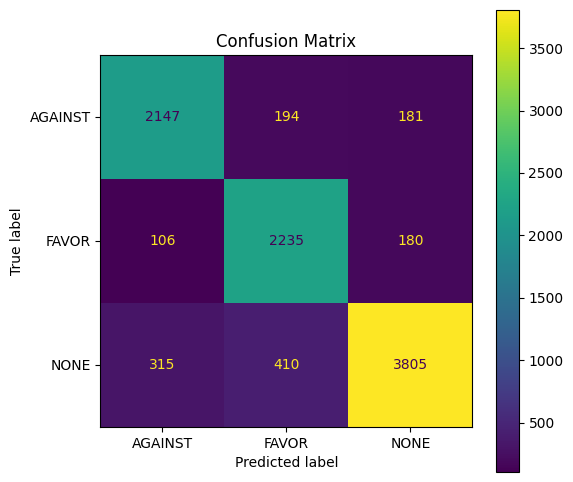

In [ ]:
# Plot the confusion matrix as a heatmap for easier inspection
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "AGAINST",
        "FAVOR",
        "NONE"
    ]

)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(ax=ax, values_format="d")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Save the best checkpoint from the weighted-loss run and its tokenizer
SAVE_DIR = "/content/drive/MyDrive/XLM-R/XLMR_Climate_Final1"

trainer.save_model(SAVE_DIR)

tokenizer.save_pretrained(SAVE_DIR)

print("Best Model Saved Successfully")

Best Model Saved Successfully


# Part 8: Inference on New Data

In [ ]:
# Defines a reusable prediction function for the weighted model, then runs it on test sets

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# =====================================================
# Load the weighted-loss fine-tuned model for inference
# =====================================================

MODEL_PATH = "/content/drive/MyDrive/XLM-R/XLMR_Climate_Final1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

model.eval()

print("Model Loaded Successfully!")

# ==========================================
# Label Mapping
# ==========================================

label_map = {
    0: "AGAINST",
    1: "FAVOR",
    2: "NONE"
}

# ==========================================
# Prediction Function
# ==========================================

def predict(text):

    inputs = tokenizer(
        str(text),
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():

        outputs = model(**inputs)

        pred = torch.argmax(outputs.logits, dim=1).item()

    return label_map[pred]

Model Loaded Successfully!


In [ ]:
# Run the weighted model's predictions on the Hindi test set and save results
hindi_test = pd.read_excel("/content/Hindi_500_test data.xlsx")

print(hindi_test.head())

hindi_test["Predicted_Label"] = hindi_test["COMMENT"].apply(predict)

hindi_test.to_excel(
    "/content/Hindi_500_Predictions_2.xlsx",
    index=False
)

print("Hindi Prediction Saved Successfully!")

   ID                                            COMMENT
0   1  बिल नाई एक वैज्ञानिक नहीं हैं। वह एक यांत्रिक ...
1   2           ऑनलाइन कक्षाओं के लिए और कौन उपस्थित है?
2   3  शाकाहारियों को इतना परेशान करने वाला क्यों होत...
3   4                      विवरण में बिल न्ये मर्च लिंक।
4   5  बिल के प्रति इतना घृणा क्यों है? मुझे समझ नहीं...
Hindi Prediction Saved Successfully!


In [ ]:
# Run the weighted model's predictions on the Bangla test set and save results
bangla_test = pd.read_excel("/content/Bangla_500_test data.xlsx")

print(bangla_test.head())

bangla_test["Predicted_Label"] = bangla_test["COMMENT"].apply(predict)

bangla_test.to_excel(
    "/content/Bangla_500_Predictions_2.xlsx",
    index=False
)

print("Bangla Prediction Saved Successfully!")

   ID                                            COMMENT
0   1  পৃথিবীর নৃত্য এবং অনন্ত আকাশের মধ্যে, ফিসফিস ক...
1   2  ধন্যবাদ, আপনার করা সমস্ত কিছুর জন্য এবং আপনি য...
2   3  এটি বায়ুমণ্ডলে কার্বন ডাই-অক্সাইডের ২৫০ ডিগ্র...
3   4  জলবায়ু-পরিবর্তক দেবতা-পাথর জানে যে পৃথিবীর দু...
4   5  আমার শিক্ষক আমাকে বলেছিলেন যে প্রতি ১০০ বছরে প...
Bangla Prediction Saved Successfully!
